#Cyber-attacks-analysis

This project conducts a comprehensive analysis of cybersecurity trends, leveraging structured data to extract meaningful insights into attack patterns, severity levels, and annual trends. By examining key variables such as attack type, severity, timestamps, and frequency, the analysis aims to identify significant patterns and relationships within the dataset.

Pipeline Steps:
1. Data Collection
2. Data Exploration
3. Data Cleaning
4. Data Preparation
5. Data Visualization
6. ML Model — Classification

In [2]:
#Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('All libraries imported successfully.')

All libraries imported successfully.



#Step 1 — Data Collection


In [4]:
df = pd.read_csv('ai_ml_cybersecurity_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print()
print('Column names:')
for col in df.columns:
    print(f'  - {col}')

Dataset shape: (20000, 10)
Rows: 20,000  |  Columns: 10

Column names:
  - Event ID
  - Timestamp
  - Source IP
  - Destination IP
  - User Agent
  - Attack Type
  - Attack Severity
  - Data Exfiltrated
  - Threat Intelligence
  - Response Action


In [5]:
df.head()

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated
2,0ef24a20-1d25-41fa-81b8-e19fb63e9e4c,2022-01-04 09:08:07,171.153.115.83,76.187.142.133,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...,Ransomware,High,False,Artist though type imagine food push.,Eradicated
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained
4,783fd153-6b88-44c1-8db5-d882300088cc,2021-11-24 02:04:33,120.43.64.52,113.82.34.164,Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...,Malware,Medium,False,Push always least police it range either.,Eradicated



#Step 2 — Data Exploration


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Event ID             20000 non-null  str  
 1   Timestamp            20000 non-null  str  
 2   Source IP            20000 non-null  str  
 3   Destination IP       20000 non-null  str  
 4   User Agent           20000 non-null  str  
 5   Attack Type          20000 non-null  str  
 6   Attack Severity      20000 non-null  str  
 7   Data Exfiltrated     20000 non-null  bool 
 8   Threat Intelligence  20000 non-null  str  
 9   Response Action      20000 non-null  str  
dtypes: bool(1), str(9)
memory usage: 1.4 MB


In [7]:
df.describe(include='all')

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,20000,19997,20000,20000,16327,5,4,2,20000,4
top,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2022-07-19 16:02:22,219.80.193.15,44.155.75.24,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Malware,Low,False,Crime low this behind option tax product.,Eradicated
freq,1,2,1,1,19,4081,5073,18081,1,5063


In [8]:
print('=== Unique values per categorical column ===')
for col in ['Attack Type', 'Attack Severity', 'Response Action', 'Data Exfiltrated']:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== Unique values per categorical column ===

Attack Type:
Attack Type
Malware           4081
Phishing          4056
Insider Threat    3968
Ransomware        3955
DDoS              3940
Name: count, dtype: int64

Attack Severity:
Attack Severity
Low         5073
High        5053
Critical    5025
Medium      4849
Name: count, dtype: int64

Response Action:
Response Action
Eradicated    5063
Blocked       5020
Recovered     4980
Contained     4937
Name: count, dtype: int64

Data Exfiltrated:
Data Exfiltrated
False    18081
True      1919
Name: count, dtype: int64


In [9]:
# Parse timestamps and extract time features
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year']  = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Hour']  = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

print('Date range:')
print(f'  From : {df["Timestamp"].min()}')
print(f'  To   : {df["Timestamp"].max()}')
print()
print('Events per year:')
print(df['Year'].value_counts().sort_index())

Date range:
  From : 2020-01-01 04:28:48
  To   : 2024-01-30 05:23:34

Events per year:
Year
2020    4935
2021    4836
2022    4887
2023    4965
2024     377
Name: count, dtype: int64



#Step 3 — Data Cleaning


In [10]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')

=== Missing Values ===
Event ID               0
Timestamp              0
Source IP              0
Destination IP         0
User Agent             0
Attack Type            0
Attack Severity        0
Data Exfiltrated       0
Threat Intelligence    0
Response Action        0
Year                   0
Month                  0
Hour                   0
DayOfWeek              0
dtype: int64

Total missing: 0


In [11]:
print('=== Duplicate Rows ===')
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset is clean.')

=== Duplicate Rows ===
Duplicate rows: 0
No duplicates found. Dataset is clean.


In [12]:
# Standardise text columns (strip whitespace, consistent casing)
text_cols = ['Attack Type', 'Attack Severity', 'Response Action']
for col in text_cols:
    df[col] = df[col].str.strip()

# Drop columns not useful for ML (free-text / identifiers)
df_clean = df.drop(columns=['Event ID', 'Source IP', 'Destination IP', 'User Agent', 'Threat Intelligence'])

print('Cleaned dataset columns:')
print(df_clean.columns.tolist())
print(f'Shape after cleaning: {df_clean.shape}')

Cleaned dataset columns:
['Timestamp', 'Attack Type', 'Attack Severity', 'Data Exfiltrated', 'Response Action', 'Year', 'Month', 'Hour', 'DayOfWeek']
Shape after cleaning: (20000, 9)



#Step 4 — Data Preparation


In [13]:
# Encode categorical features
le = LabelEncoder()

# Map ordinal severity to numeric
severity_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df_clean['Severity_Enc'] = df_clean['Attack Severity'].map(severity_order)

# Label-encode Attack Type and Response Action
df_clean['AttackType_Enc']     = le.fit_transform(df_clean['Attack Type'])
df_clean['ResponseAction_Enc'] = le.fit_transform(df_clean['Response Action'])

# Convert boolean exfiltration to int
df_clean['Exfiltrated'] = df_clean['Data Exfiltrated'].astype(int)

print('Encoded feature preview:')
df_clean[['Attack Type','AttackType_Enc','Attack Severity','Severity_Enc',
          'Response Action','ResponseAction_Enc','Exfiltrated']].head(8)

Encoded feature preview:


,Attack Type,AttackType_Enc,Attack Severity,Severity_Enc,Response Action,ResponseAction_Enc,Exfiltrated
0,Ransomware,4,Critical,3,Eradicated,2,0
1,Malware,2,Critical,3,Eradicated,2,1
2,Ransomware,4,High,2,Eradicated,2,0
3,DDoS,0,Critical,3,Contained,1,0
4,Malware,2,Medium,1,Eradicated,2,0
5,Insider Threat,1,Medium,1,Recovered,3,0
6,DDoS,0,Medium,1,Recovered,3,0
7,Insider Threat,1,Low,0,Blocked,0,0


In [14]:
# Target: predict Attack Severity (4-class classification)
feature_cols = ['AttackType_Enc', 'Exfiltrated', 'ResponseAction_Enc', 'Year', 'Month', 'Hour']
target_col   = 'Severity_Enc'

X = df_clean[feature_cols]
y = df_clean[target_col]

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Features used    : {feature_cols}')
print(f'Target classes   : {sorted(y.unique())}  (0=Low, 1=Medium, 2=High, 3=Critical)')

Training samples : 16,000
Test samples     : 4,000
Features used    : ['AttackType_Enc', 'Exfiltrated', 'ResponseAction_Enc', 'Year', 'Month', 'Hour']
Target classes   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (0=Low, 1=Medium, 2=High, 3=Critical)



#Step 5 — Data Visualization


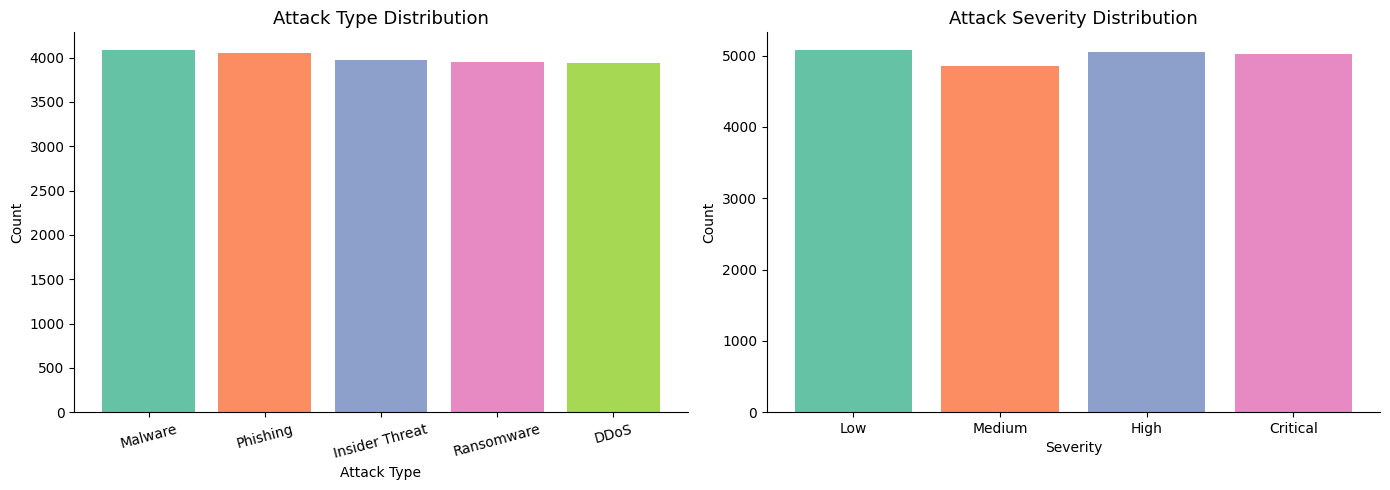

In [15]:
# 5.1  Attack type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attack_counts = df['Attack Type'].value_counts()
axes[0].bar(attack_counts.index, attack_counts.values, color=sns.color_palette('Set2', 5))
axes[0].set_title('Attack Type Distribution', fontsize=13)
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

severity_counts = df['Attack Severity'].value_counts().reindex(['Low','Medium','High','Critical'])
axes[1].bar(severity_counts.index, severity_counts.values, color=sns.color_palette('Set2', 4))
axes[1].set_title('Attack Severity Distribution', fontsize=13)
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

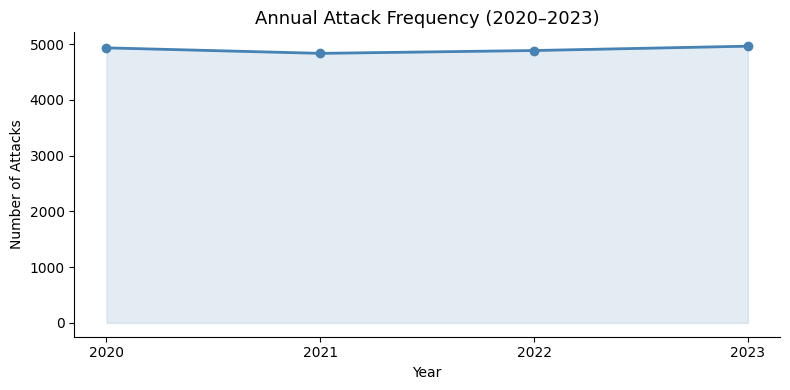

In [16]:
# 5.2  Attacks per year (excluding partial 2024)
yearly = df[df['Year'] < 2024].groupby('Year').size()

plt.figure(figsize=(8, 4))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
plt.title('Annual Attack Frequency (2020–2023)', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.xticks(yearly.index)
plt.tight_layout()
plt.show()

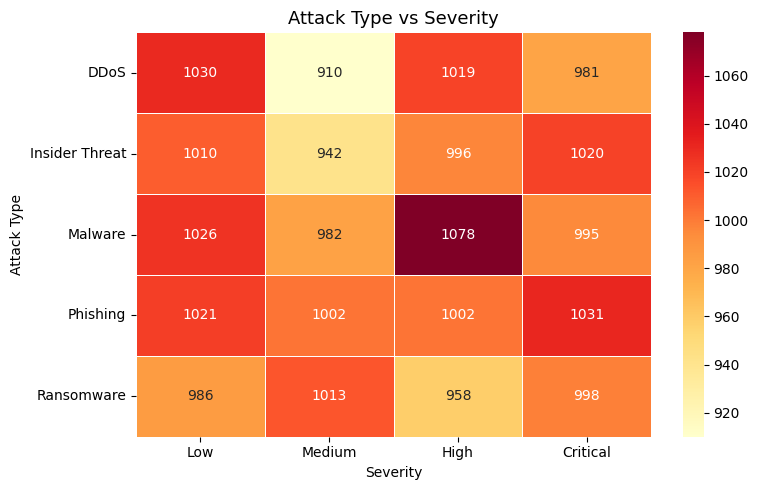

In [17]:
# 5.3  Attack type vs severity heatmap
pivot = pd.crosstab(df['Attack Type'], df['Attack Severity'])[['Low','Medium','High','Critical']]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Attack Type vs Severity', fontsize=13)
plt.xlabel('Severity')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()

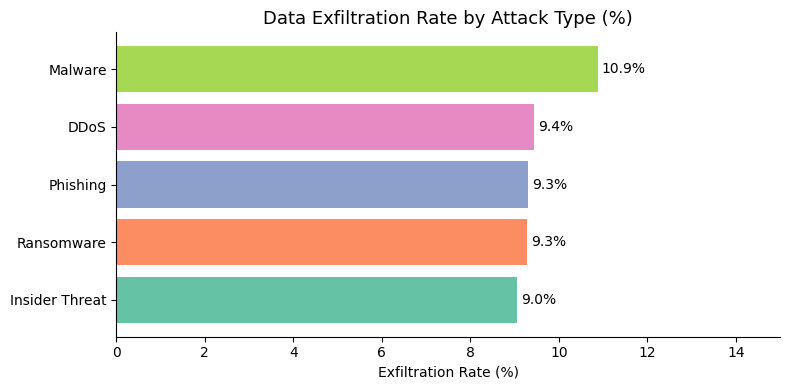

In [18]:
# 5.4  Data exfiltration rate by attack type
exfil_rate = df.groupby('Attack Type')['Data Exfiltrated'].mean().mul(100).sort_values()

plt.figure(figsize=(8, 4))
bars = plt.barh(exfil_rate.index, exfil_rate.values, color=sns.color_palette('Set2', len(exfil_rate)))
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.title('Data Exfiltration Rate by Attack Type (%)', fontsize=13)
plt.xlabel('Exfiltration Rate (%)')
plt.xlim(0, 15)
plt.tight_layout()
plt.show()

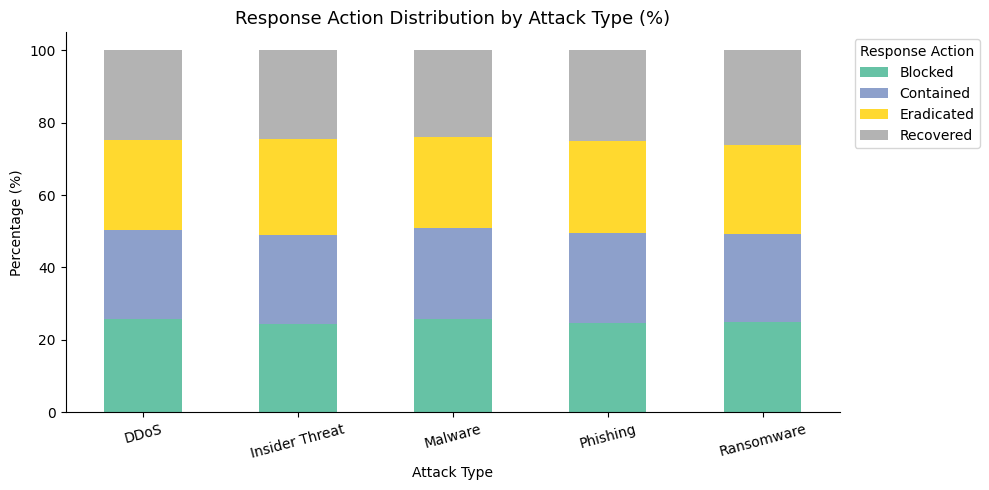

In [19]:
# 5.5  Response action by attack type
response_pivot = pd.crosstab(df['Attack Type'], df['Response Action'], normalize='index').mul(100)

response_pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Response Action Distribution by Attack Type (%)', fontsize=13)
plt.xlabel('Attack Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Response Action', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

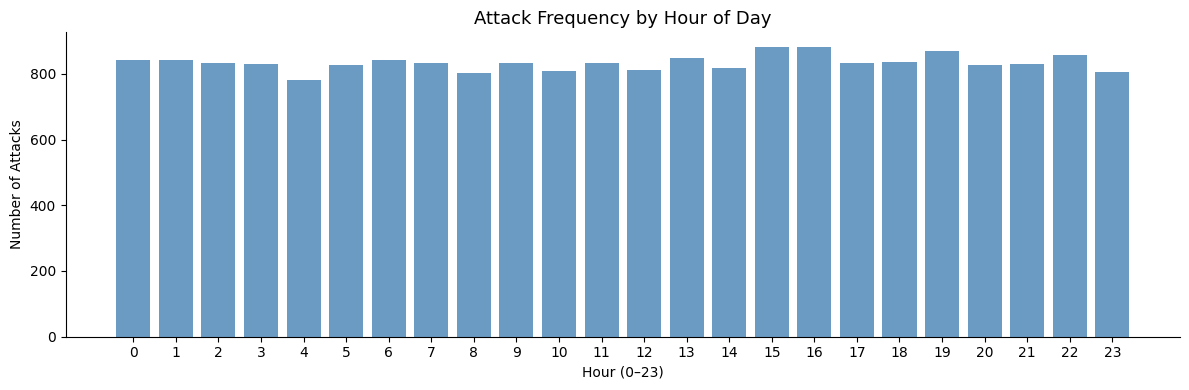

In [20]:
# 5.6  Attacks by hour of day
hourly = df.groupby('Hour').size()

plt.figure(figsize=(12, 4))
plt.bar(hourly.index, hourly.values, color='steelblue', alpha=0.8)
plt.title('Attack Frequency by Hour of Day', fontsize=13)
plt.xlabel('Hour (0–23)')
plt.ylabel('Number of Attacks')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


#Step 5 Additional Visualizations

Covers all major chart types: Pie · Exploded Pie · Line · Histogram · Violin · Box · Scatter · Dot · Bubble · Heatmap · Stacked Bar · Joint Plot

#5.7  Bar Charts — Seaborn Countplot

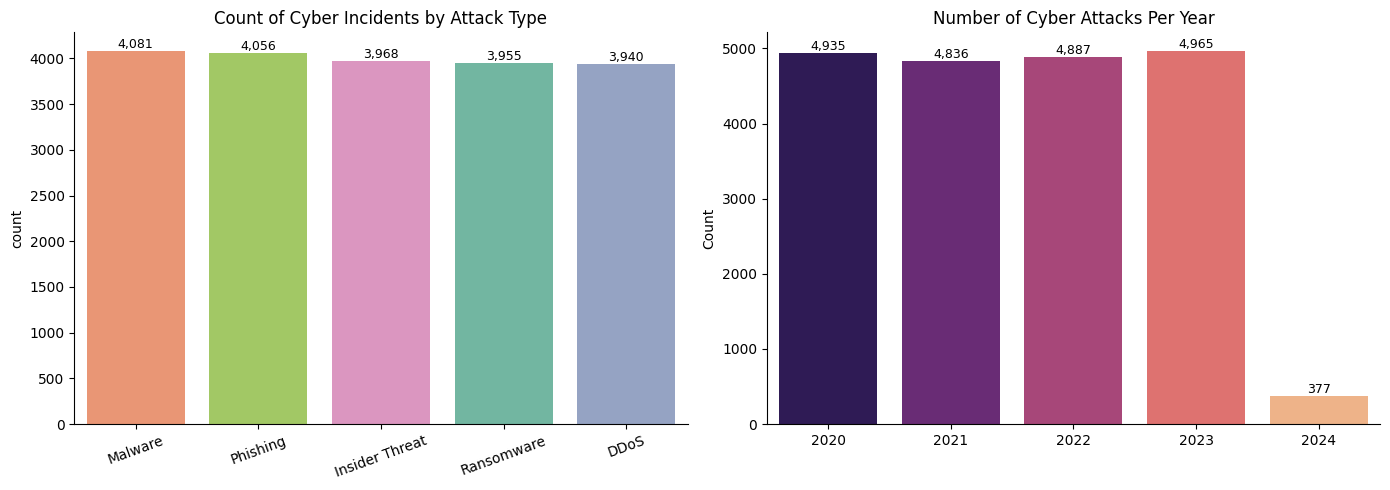

In [21]:
# Bar Chart 1: Attack Type Count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Attack Type', hue='Attack Type',
              order=df['Attack Type'].value_counts().index,
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Count of Cyber Incidents by Attack Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Bar Chart 2: Attacks per Year
yr = df['Year'].value_counts().sort_index().reset_index()
yr.columns = ['Year','Count']
sns.barplot(data=yr, x='Year', y='Count', palette='magma', ax=axes[1])
axes[1].set_title('Number of Cyber Attacks Per Year')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#5.8  Line Plots — Yearly Trends


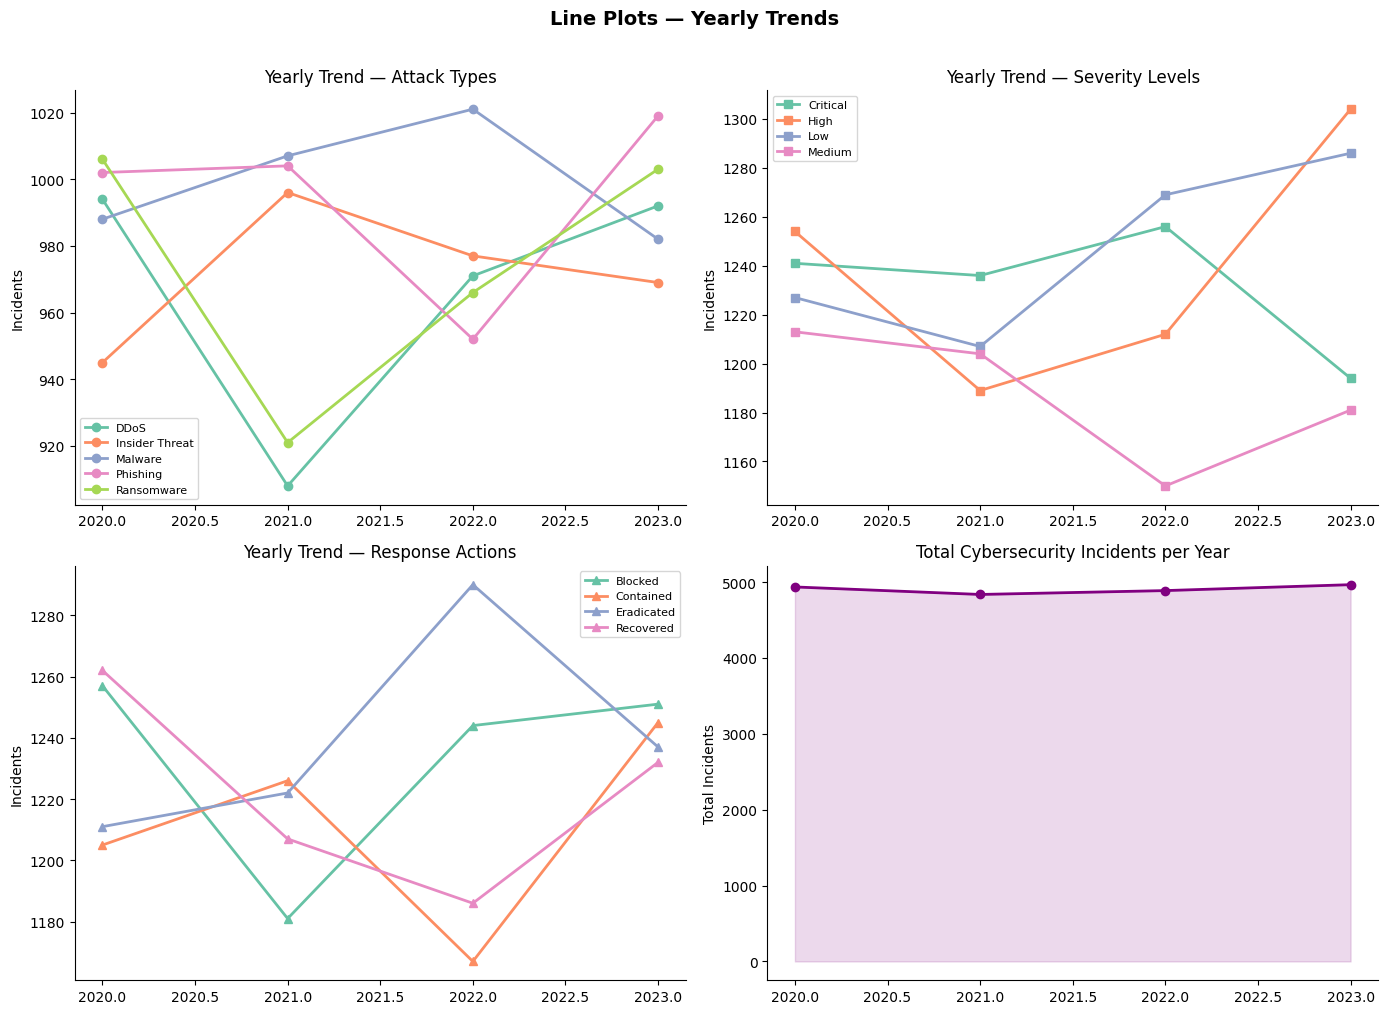

In [22]:
df_main = df[df['Year'] < 2024].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Line Plots — Yearly Trends', fontsize=14, fontweight='bold', y=1.01)

# Attack Type trend
at_trend = df_main.groupby(['Year','Attack Type']).size().unstack(fill_value=0)
for col in at_trend.columns:
    axes[0,0].plot(at_trend.index, at_trend[col], marker='o', linewidth=2, label=col)
axes[0,0].set_title('Yearly Trend — Attack Types')
axes[0,0].set_ylabel('Incidents')
axes[0,0].legend(fontsize=8)

# Severity trend
sev_trend = df_main.groupby(['Year','Attack Severity']).size().unstack(fill_value=0)
for col in sev_trend.columns:
    axes[0,1].plot(sev_trend.index, sev_trend[col], marker='s', linewidth=2, label=col)
axes[0,1].set_title('Yearly Trend — Severity Levels')
axes[0,1].set_ylabel('Incidents')
axes[0,1].legend(fontsize=8)

# Response Action trend
resp_trend = df_main.groupby(['Year','Response Action']).size().unstack(fill_value=0)
for col in resp_trend.columns:
    axes[1,0].plot(resp_trend.index, resp_trend[col], marker='^', linewidth=2, label=col)
axes[1,0].set_title('Yearly Trend — Response Actions')
axes[1,0].set_ylabel('Incidents')
axes[1,0].legend(fontsize=8)

# Total incidents per year
total_trend = df_main.groupby('Year').size()
axes[1,1].plot(total_trend.index, total_trend.values, marker='o', color='purple', linewidth=2)
axes[1,1].fill_between(total_trend.index, total_trend.values, alpha=0.15, color='purple')
axes[1,1].set_title('Total Cybersecurity Incidents per Year')
axes[1,1].set_ylabel('Total Incidents')

plt.tight_layout()
plt.show()


#5.9  Histogram — Top 5 Peak Attack Hours


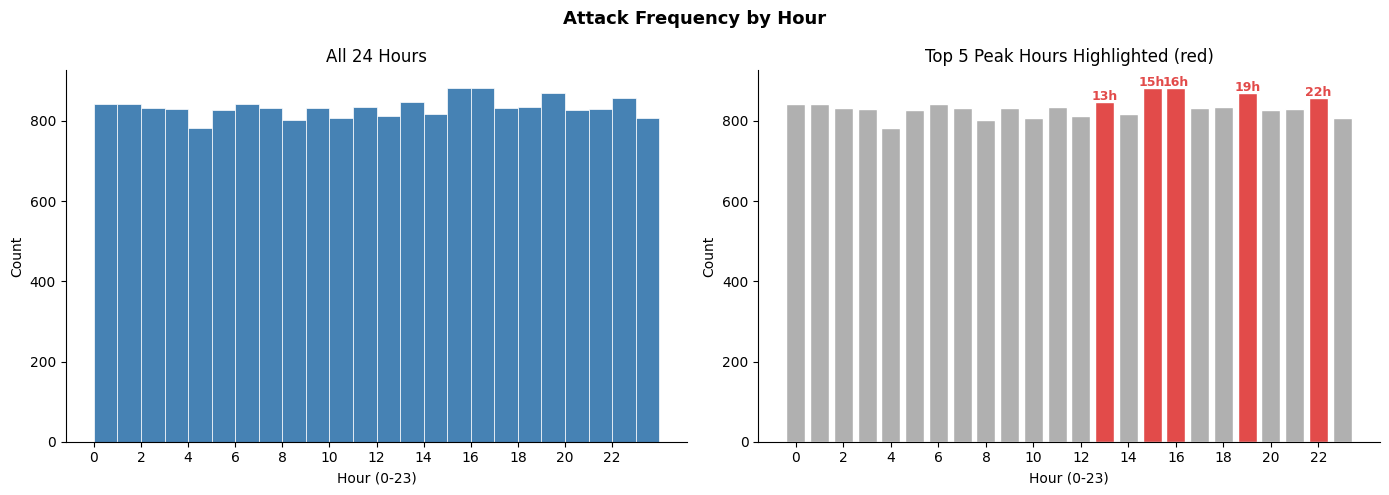

In [23]:
top5_hours = df['Hour'].value_counts().nlargest(5).sort_index()
hour_counts = df['Hour'].value_counts().sort_index()
colors = ['#E24B4A' if h in top5_hours.index else '#b0b0b0' for h in hour_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attack Frequency by Hour', fontsize=13, fontweight='bold')

# All hours histogram
axes[0].hist(df['Hour'].dropna(), bins=24, range=(0,24),
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('All 24 Hours')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0,24,2))

# Top 5 hours highlighted
axes[1].bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Top 5 Peak Hours Highlighted (red)')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(0,24,2))
for h in top5_hours.index:
    axes[1].annotate(f'{h}h', (h, hour_counts[h]+5),
                     ha='center', fontsize=9, color='#E24B4A', fontweight='bold')

plt.tight_layout()
plt.show()


#5.10  Pie Charts — Proportional Distributions


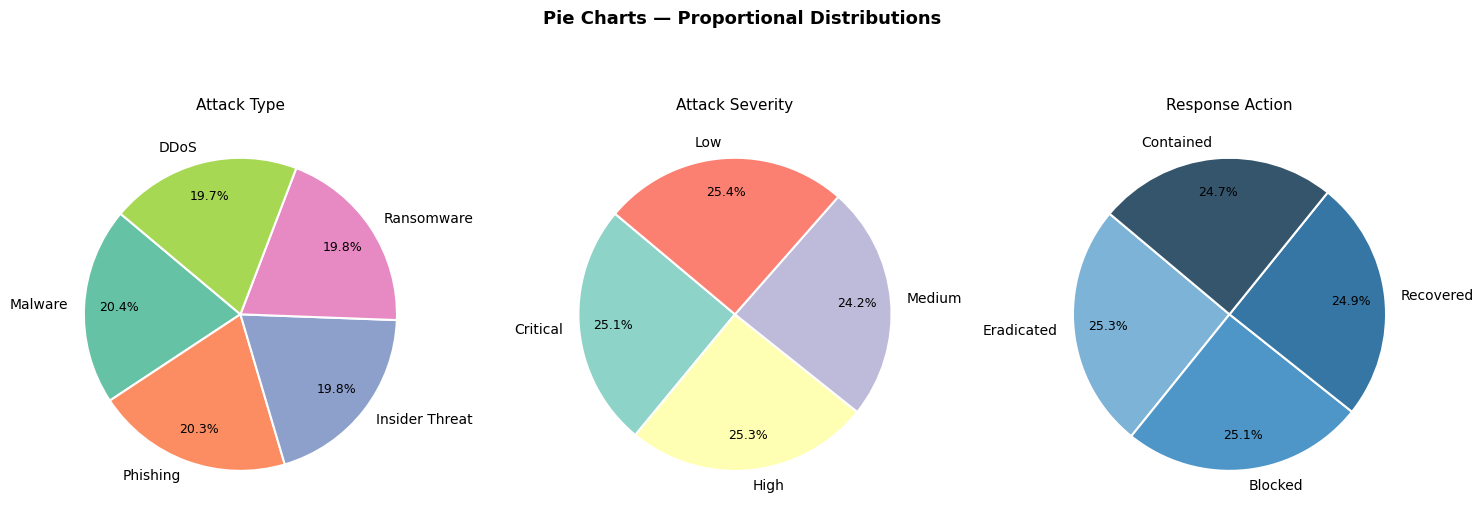

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Pie Charts — Proportional Distributions', fontsize=13, fontweight='bold')

def make_pie(ax, data, title, colors):
    wedges, texts, autotexts = ax.pie(
        data.values, labels=data.index, autopct='%1.1f%%',
        startangle=140, colors=colors, pctdistance=0.78,
        wedgeprops=dict(linewidth=1.5, edgecolor='white'))
    for at in autotexts: at.set_fontsize(9)
    ax.set_title(title, fontsize=11)

make_pie(axes[0], df['Attack Type'].value_counts(), 'Attack Type', sns.color_palette('Set2', 5))
make_pie(axes[1], df['Attack Severity'].value_counts().reindex(['Critical','High','Medium','Low']),
         'Attack Severity', sns.color_palette('Set3', 4))
make_pie(axes[2], df['Response Action'].value_counts(), 'Response Action', sns.color_palette('Blues_d', 4))

plt.tight_layout()
plt.show()


#5.11  Exploded Pie — Smallest Slice Popped Out


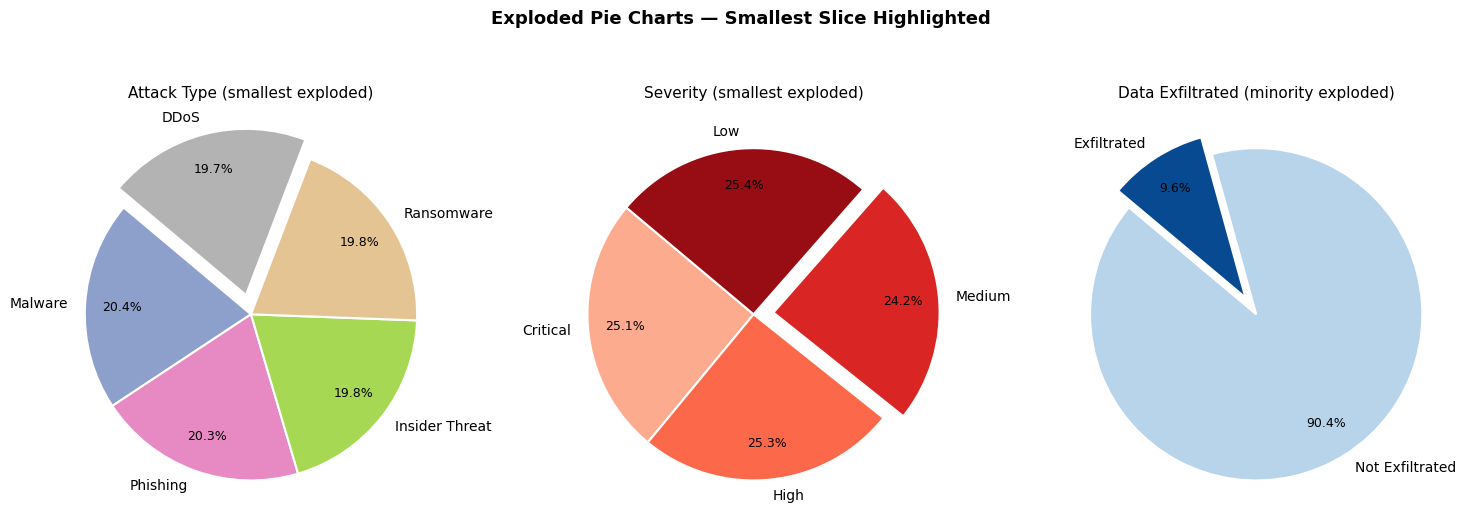

In [25]:
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Exploded Pie Charts — Smallest Slice Highlighted', fontsize=13, fontweight='bold')

def exploded_pie(ax, data, title, cmap):
    explode = [0.12 if v == data.min() else 0 for v in data.values]
    colors = cmap(np.linspace(0.3, 0.9, len(data)))
    wedges, texts, autotexts = ax.pie(
        data.values, labels=data.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=explode,
        pctdistance=0.78, wedgeprops=dict(linewidth=1.5, edgecolor='white'))
    for at in autotexts: at.set_fontsize(9)
    ax.set_title(title, fontsize=11)

exploded_pie(axes[0], df['Attack Type'].value_counts(), 'Attack Type (smallest exploded)', plt.cm.Set2)
exploded_pie(axes[1], df['Attack Severity'].value_counts().reindex(['Critical','High','Medium','Low']),
             'Severity (smallest exploded)', plt.cm.Reds)
exfil_data = df['Data Exfiltrated'].map({True:'Exfiltrated',False:'Not Exfiltrated'}).value_counts()
exploded_pie(axes[2], exfil_data, 'Data Exfiltrated (minority exploded)', plt.cm.Blues)

plt.tight_layout()
plt.show()


#5.12  Box Plots — Monthly Frequency Statistics


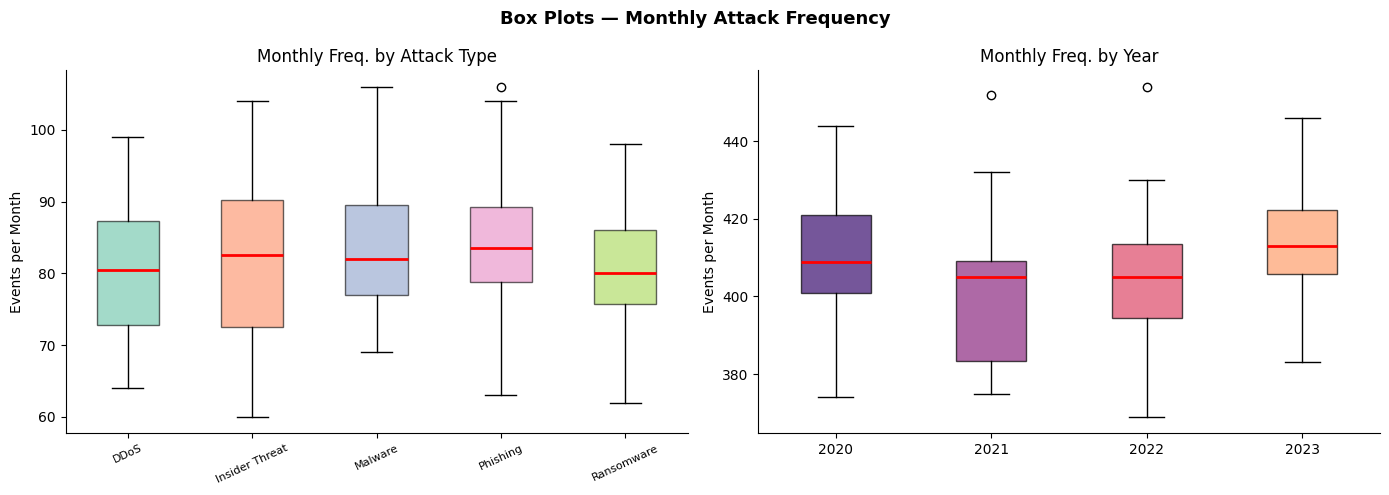

In [26]:
monthly_df = df[df['Year']<2024].groupby(['Year','Month','Attack Type']).size().reset_index(name='Count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Box Plots — Monthly Attack Frequency', fontsize=13, fontweight='bold')

# By attack type
types = monthly_df['Attack Type'].unique()
data_by_type = [monthly_df[monthly_df['Attack Type']==t]['Count'].values for t in types]
bp = axes[0].boxplot(data_by_type, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(types))):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_xticklabels(types, rotation=25, fontsize=8)
axes[0].set_title('Monthly Freq. by Attack Type')
axes[0].set_ylabel('Events per Month')

# By year
data_by_year = [df[df['Year']==y].groupby('Month').size().values for y in [2020,2021,2022,2023]]
bp2 = axes[1].boxplot(data_by_year, patch_artist=True,
                      medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp2['boxes'], sns.color_palette('magma', 4)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels([2020,2021,2022,2023])
axes[1].set_title('Monthly Freq. by Year')
axes[1].set_ylabel('Events per Month')

plt.tight_layout()
plt.show()


#5.13  Violin Plots — Distribution Shape by Category


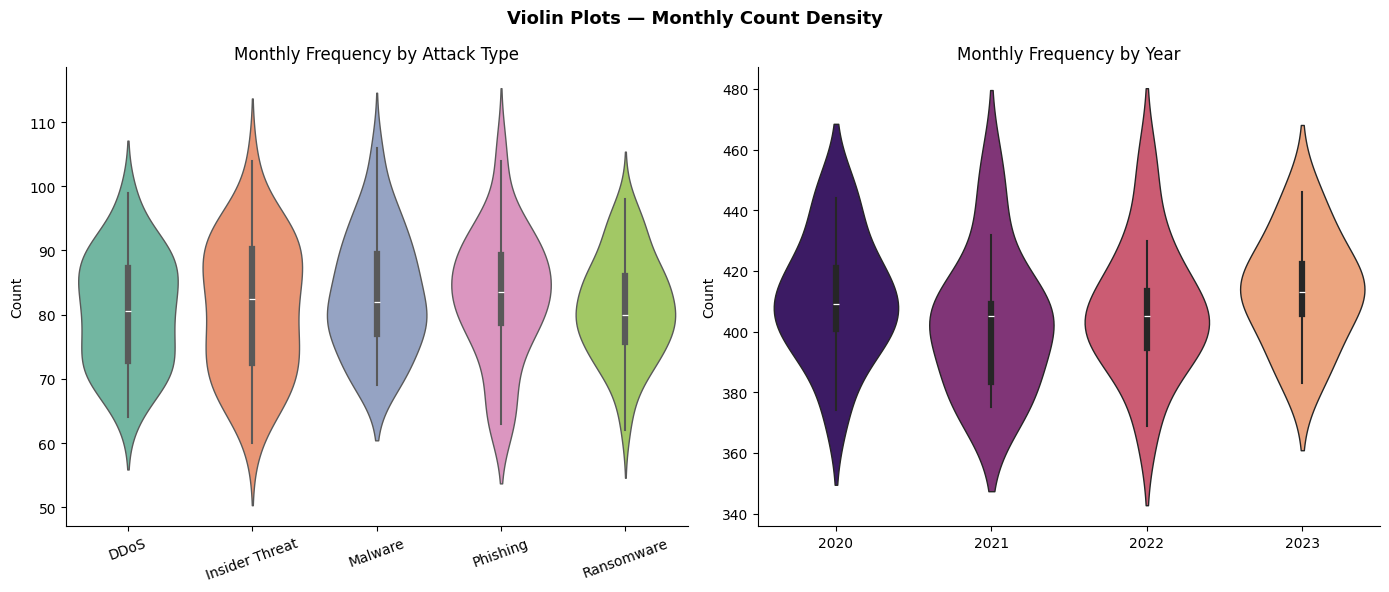

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Violin Plots — Monthly Count Density', fontsize=13, fontweight='bold')

# By attack type
sns.violinplot(data=monthly_df, x='Attack Type', y='Count',
               hue='Attack Type', palette='Set2', inner='box',
               linewidth=1, legend=False, ax=axes[0])
axes[0].set_title('Monthly Frequency by Attack Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# By year
yr_df = df[df['Year']<2024].groupby(['Year','Month']).size().reset_index(name='Count')
yr_df['Year'] = yr_df['Year'].astype(str)
sns.violinplot(data=yr_df, x='Year', y='Count', hue='Year',
               palette='magma', inner='box', linewidth=1,
               legend=False, ax=axes[1])
axes[1].set_title('Monthly Frequency by Year')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


#5.14  Scatter Plots — Jittered Categorical Variables


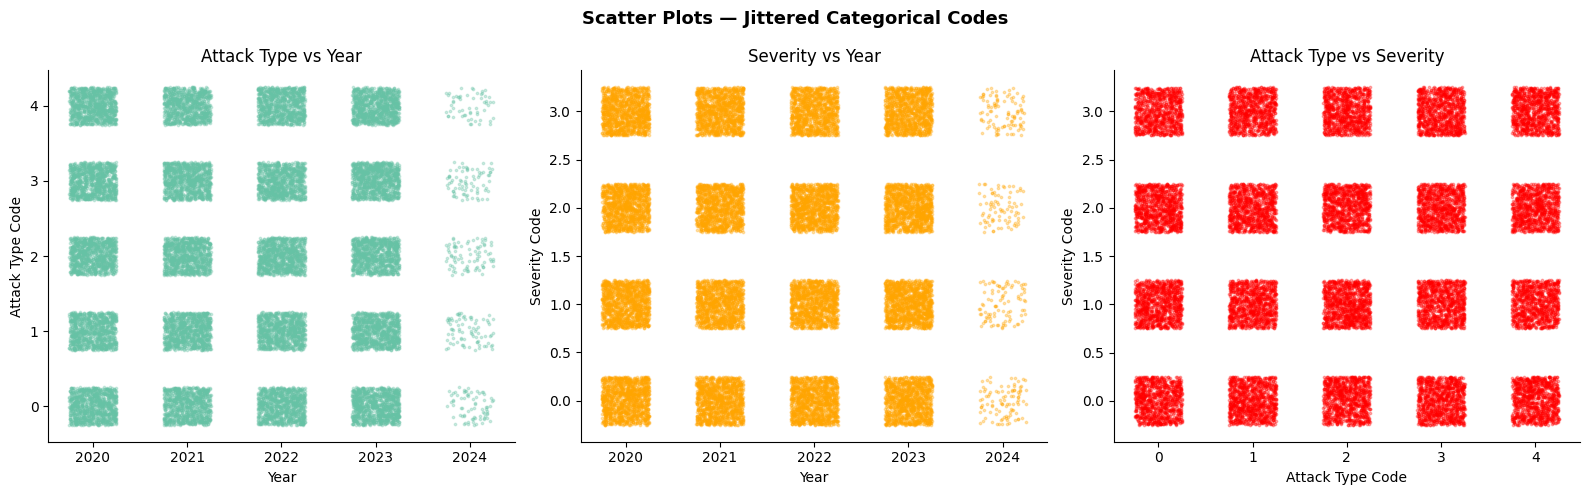

In [28]:
import numpy as np
rng = np.random.default_rng(42)
def jitter(arr, scale=0.25):
    return arr + rng.uniform(-scale, scale, size=arr.shape)

df['AttackType_Code'] = df['Attack Type'].astype('category').cat.codes
df['Severity_Code']   = df['Attack Severity'].astype('category').cat.codes
df['Response_Code']   = df['Response Action'].astype('category').cat.codes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scatter Plots — Jittered Categorical Codes', fontsize=13, fontweight='bold')

axes[0].scatter(jitter(df['Year'].values.astype(float)),
                jitter(df['AttackType_Code'].values.astype(float)), alpha=0.3, s=3)
axes[0].set_title('Attack Type vs Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Attack Type Code')

axes[1].scatter(jitter(df['Year'].values.astype(float)),
                jitter(df['Severity_Code'].values.astype(float)),
                alpha=0.3, s=3, color='orange')
axes[1].set_title('Severity vs Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Severity Code')

axes[2].scatter(jitter(df['AttackType_Code'].values.astype(float)),
                jitter(df['Severity_Code'].values.astype(float)),
                alpha=0.3, s=3, color='red')
axes[2].set_title('Attack Type vs Severity')
axes[2].set_xlabel('Attack Type Code')
axes[2].set_ylabel('Severity Code')

plt.tight_layout()
plt.show()


#5.15  Dot Plots — Count Comparisons


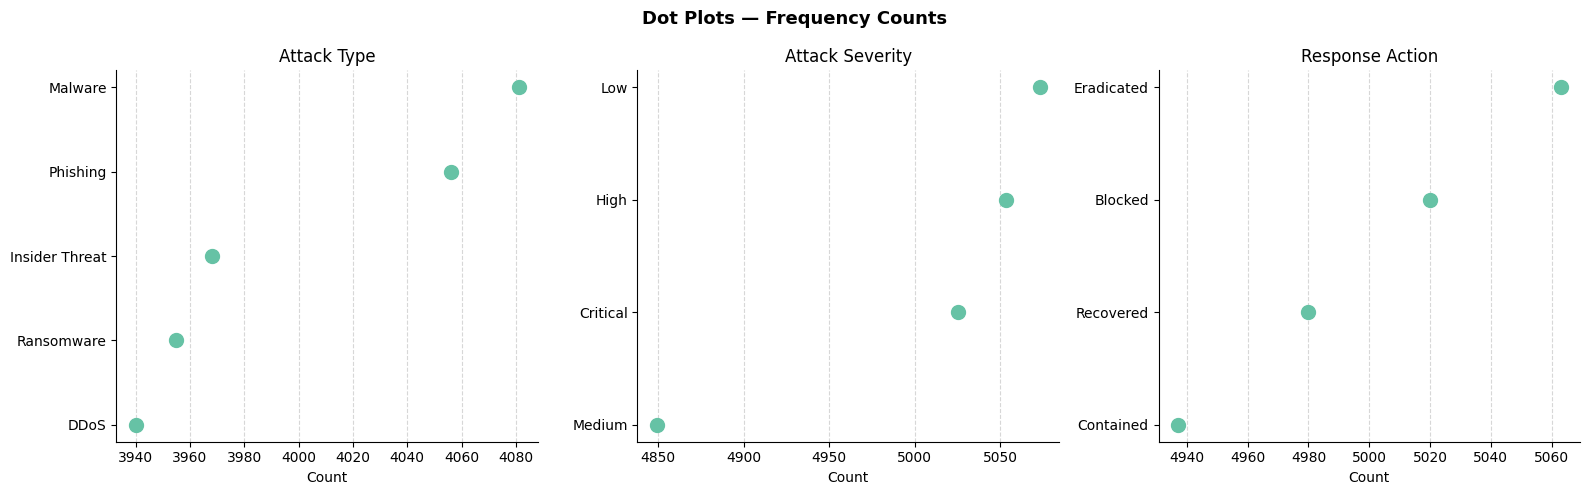

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dot Plots — Frequency Counts', fontsize=13, fontweight='bold')

def dot_plot(ax, series, title):
    counts = series.value_counts().sort_values()
    ax.plot(counts.values, counts.index, 'o', markersize=10)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

dot_plot(axes[0], df['Attack Type'], 'Attack Type')
dot_plot(axes[1], df['Attack Severity'], 'Attack Severity')
dot_plot(axes[2], df['Response Action'], 'Response Action')

plt.tight_layout()
plt.show()


#5.16  Bubble Chart — Attack Type × Severity (bubble = frequency)


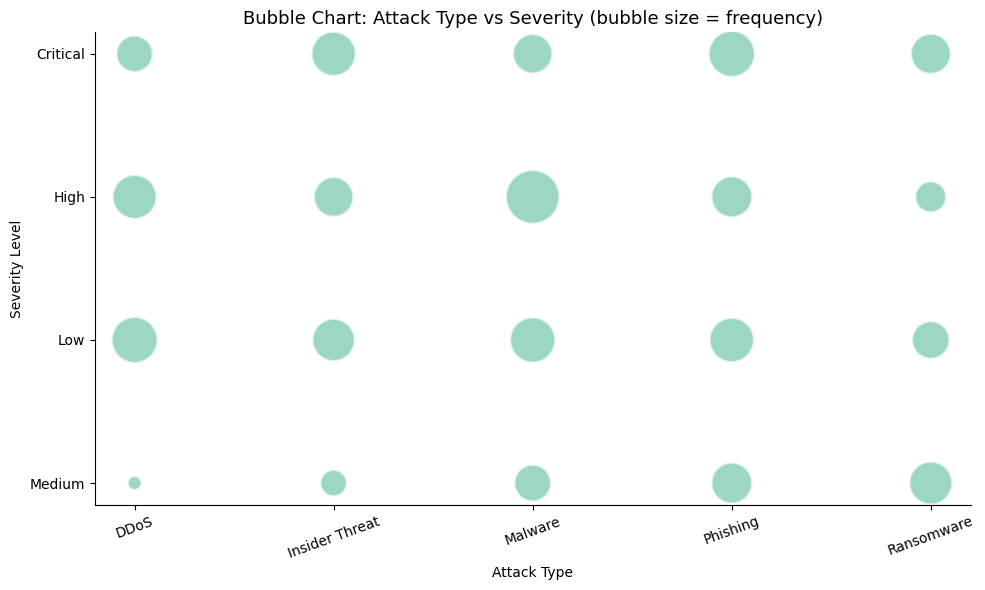

In [30]:
bubble_data = df.groupby(['Attack Type','Attack Severity']).size().reset_index(name='Count')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=bubble_data, x='Attack Type', y='Attack Severity',
                size='Count', sizes=(100, 1500),
                alpha=0.65, legend=False)
plt.title('Bubble Chart: Attack Type vs Severity (bubble size = frequency)', fontsize=13)
plt.xlabel('Attack Type')
plt.ylabel('Severity Level')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#5.17  Heatmaps — Cross-Dimensional Analysis


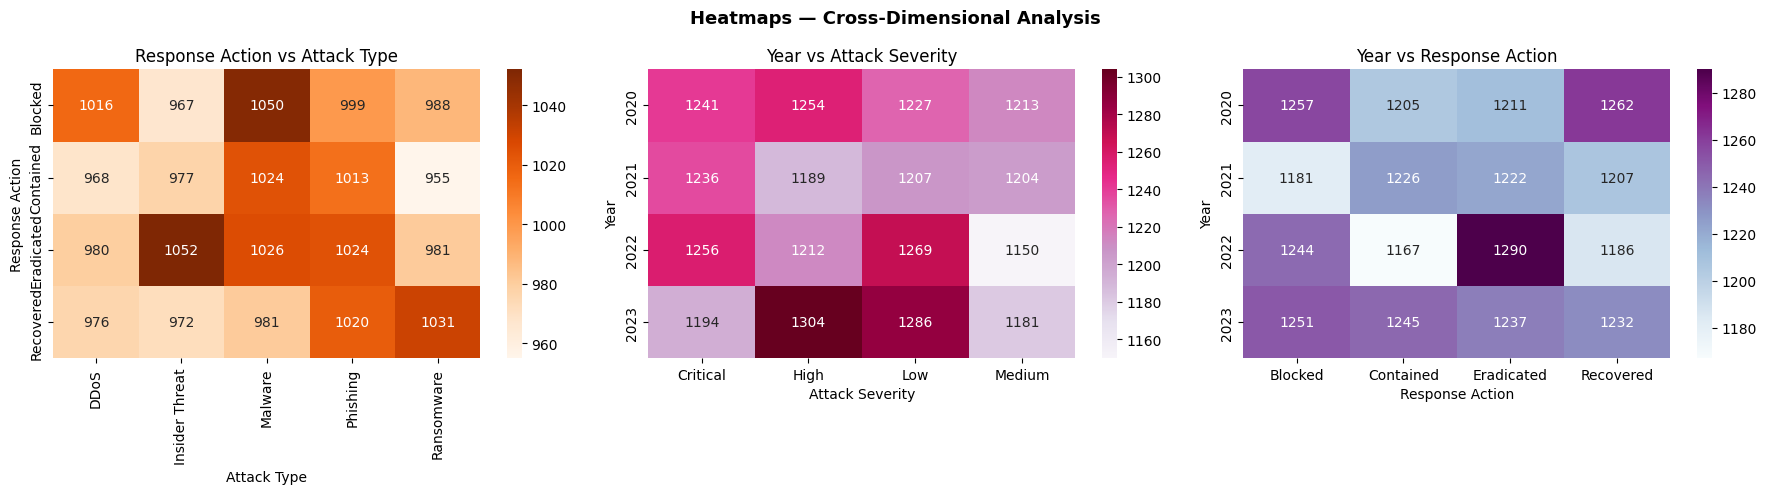

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Heatmaps — Cross-Dimensional Analysis', fontsize=13, fontweight='bold')

# Response Action vs Attack Type
pivot1 = df.pivot_table(index='Response Action', columns='Attack Type', aggfunc='size', fill_value=0)
sns.heatmap(pivot1, annot=True, cmap='Oranges', fmt='d', ax=axes[0])
axes[0].set_title('Response Action vs Attack Type')

# Year vs Severity
pivot2 = df[df['Year']<2024].pivot_table(index='Year', columns='Attack Severity', aggfunc='size', fill_value=0)
sns.heatmap(pivot2, annot=True, cmap='PuRd', fmt='d', ax=axes[1])
axes[1].set_title('Year vs Attack Severity')

# Year vs Response Action
pivot3 = df[df['Year']<2024].pivot_table(index='Year', columns='Response Action', aggfunc='size', fill_value=0)
sns.heatmap(pivot3, annot=True, cmap='BuPu', fmt='d', ax=axes[2])
axes[2].set_title('Year vs Response Action')

plt.tight_layout()
plt.show()


#5.18  Stacked Bar Chart — Attack Types per Year


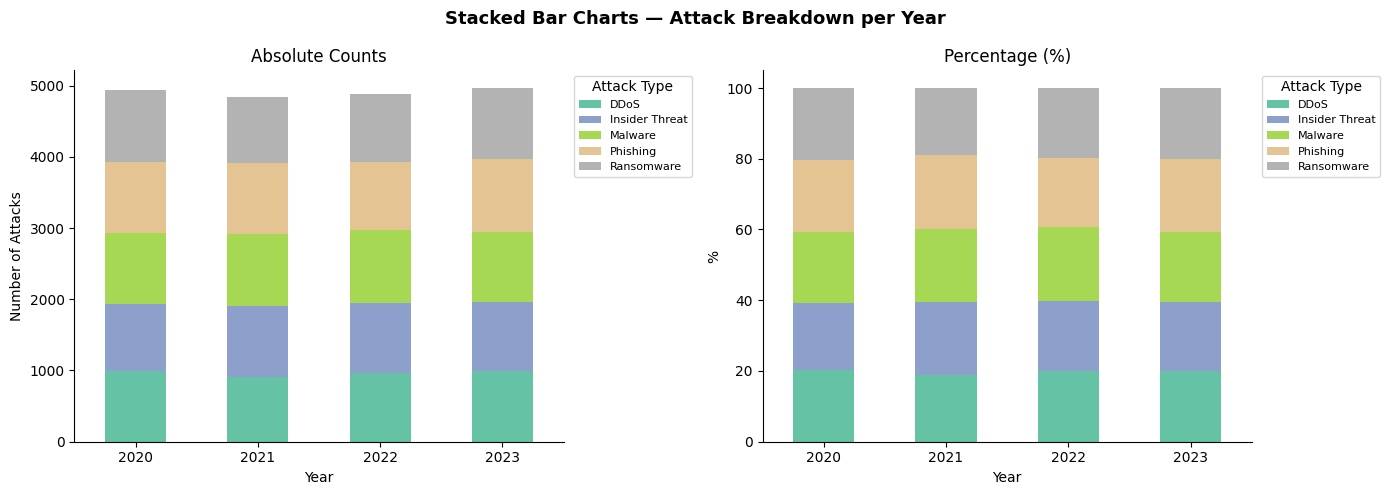

In [32]:
attack_year = df[df['Year']<2024].groupby(['Year','Attack Type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stacked Bar Charts — Attack Breakdown per Year', fontsize=13, fontweight='bold')

# Absolute counts
attack_year.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])
axes[0].set_title('Absolute Counts')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Attacks')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Attack Type', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

# Percentage
attack_year_pct = attack_year.div(attack_year.sum(axis=1), axis=0).mul(100)
attack_year_pct.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Percentage (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Attack Type', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


#5.19  Joint Plots — Year vs Annual Attack Count


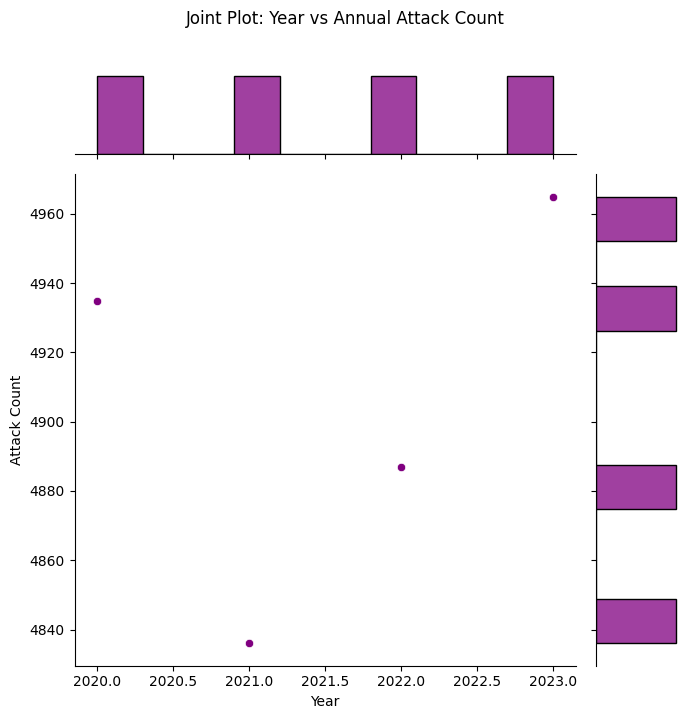

In [33]:
year_counts = df[df['Year']<2024]['Year'].value_counts().reset_index()
year_counts.columns = ['Year','Attack Count']

# Joint plot — scatter + marginal histograms
g = sns.jointplot(data=year_counts, x='Year', y='Attack Count',
                  kind='scatter', marginal_kws=dict(bins=10, fill=True),
                  color='purple', height=7)
g.fig.suptitle('Joint Plot: Year vs Annual Attack Count', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


#5.20  Bar Chart — Attack Frequency by Day of Week


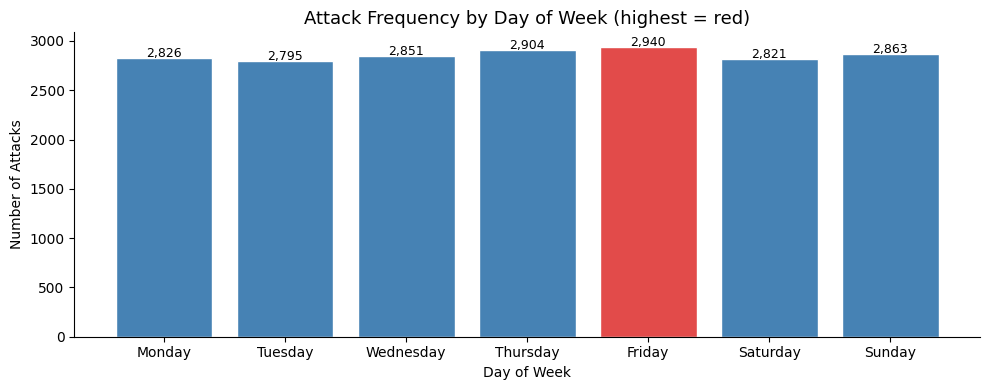

In [34]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df['DayOfWeek'].value_counts().reindex(dow_order)

plt.figure(figsize=(10, 4))
colors = ['#E24B4A' if v == dow_counts.max() else 'steelblue' for v in dow_counts.values]
plt.bar(dow_counts.index, dow_counts.values, color=colors, edgecolor='white')
plt.title('Attack Frequency by Day of Week (highest = red)', fontsize=13)
plt.xlabel('Day of Week')
plt.ylabel('Number of Attacks')
for i, v in enumerate(dow_counts.values):
    plt.text(i, v+10, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


#5.21  Heatmap — Exfiltration Rate by Attack Type × Severity


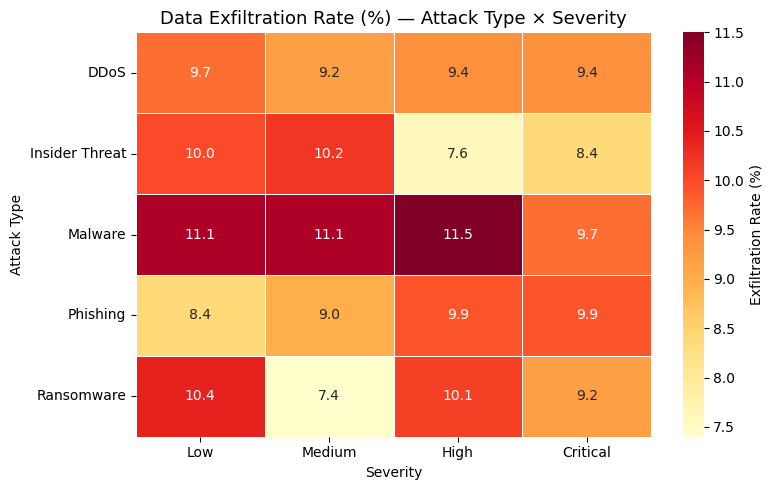

In [35]:
exfil_heat = df.groupby(['Attack Type','Attack Severity'])['Data Exfiltrated'].mean().mul(100).round(1).unstack()
exfil_heat = exfil_heat[['Low','Medium','High','Critical']]

plt.figure(figsize=(8, 5))
sns.heatmap(exfil_heat, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Exfiltration Rate (%)'})
plt.title('Data Exfiltration Rate (%) — Attack Type × Severity', fontsize=13)
plt.xlabel('Severity')
plt.ylabel('Attack Type')
plt.tight_layout()
plt.show()


#Step 6 — ML Model: Classification

<!-- **Objective:** Predict the **Attack Severity** (Low / Medium / High / Critical) based on available features.

Two models are compared:
- Logistic Regression (baseline)
- Random Forest Classifier -->

In [36]:
# 6.1  Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Low','Medium','High','Critical']
))

=== Logistic Regression ===
Accuracy: 0.2370

              precision    recall  f1-score   support

         Low       0.23      0.26      0.25      1015
      Medium       0.21      0.10      0.13       970
        High       0.25      0.29      0.27      1010
    Critical       0.24      0.29      0.26      1005

    accuracy                           0.24      4000
   macro avg       0.23      0.24      0.23      4000
weighted avg       0.23      0.24      0.23      4000



In [37]:
# 6.2  Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # RF does not require scaling
y_pred_rf = rf.predict(X_test)

print('=== Random Forest Classifier ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Low','Medium','High','Critical']
))

=== Random Forest Classifier ===
Accuracy: 0.2385

              precision    recall  f1-score   support

         Low       0.24      0.23      0.24      1015
      Medium       0.23      0.23      0.23       970
        High       0.24      0.24      0.24      1010
    Critical       0.25      0.25      0.25      1005

    accuracy                           0.24      4000
   macro avg       0.24      0.24      0.24      4000
weighted avg       0.24      0.24      0.24      4000



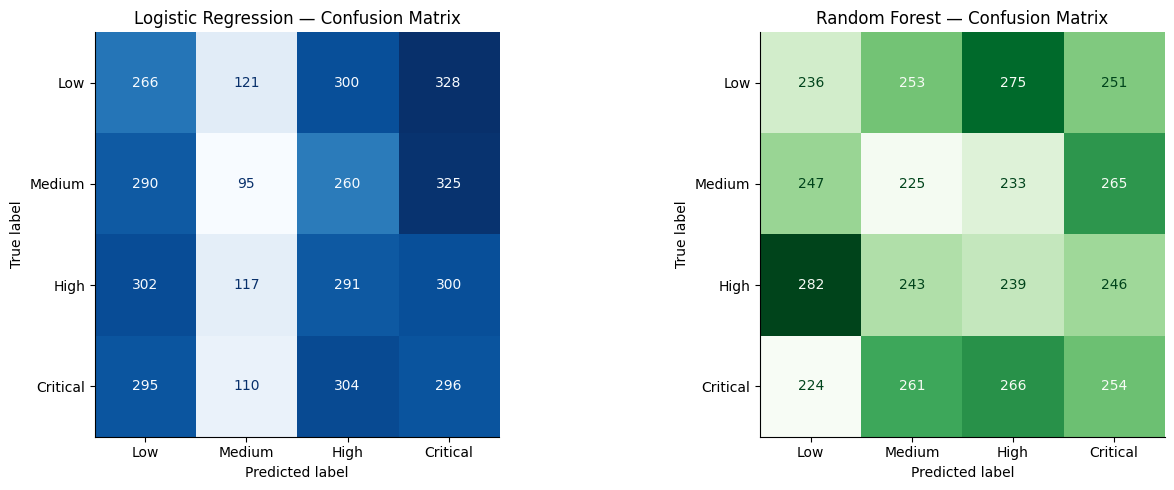

In [38]:
# 6.3  Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Low','Medium','High','Critical']

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=labels
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=labels
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest — Confusion Matrix')

plt.tight_layout()
plt.show()

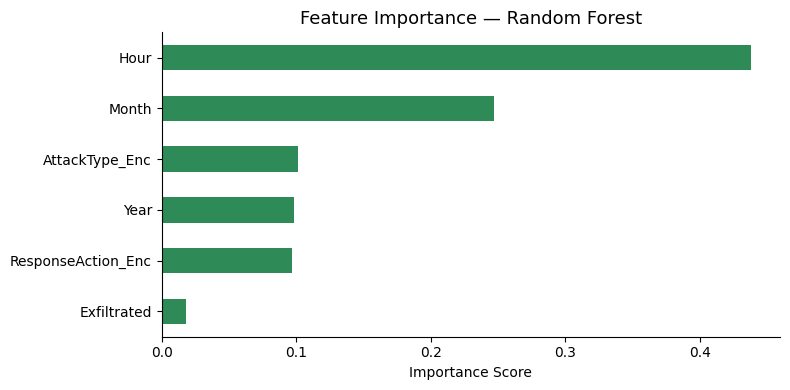


Feature importances:
Hour                  0.437912
Month                 0.247187
AttackType_Enc        0.101261
Year                  0.098101
ResponseAction_Enc    0.097204
Exfiltrated           0.018335


In [39]:
# 6.4  Feature importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='seagreen')
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature importances:')
print(importances.sort_values(ascending=False).to_string())

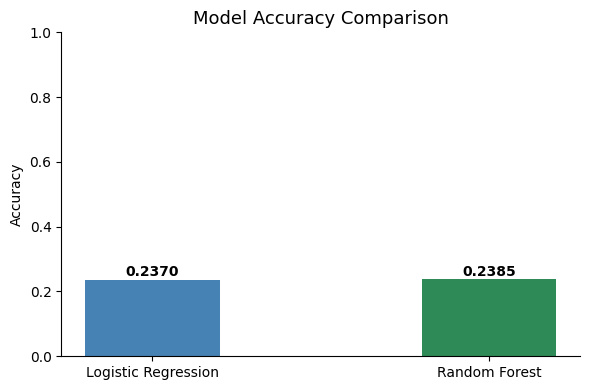

              Model  Accuracy
Logistic Regression    0.2370
      Random Forest    0.2385


In [40]:
# 6.5  Model comparison summary
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ]
})

plt.figure(figsize=(6, 4))
plt.bar(results['Model'], results['Accuracy'], color=['steelblue','seagreen'], width=0.4)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Accuracy')
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(results.to_string(index=False))